In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 
import flamingo_tangos as ft
import tangos as db

db.init_db('data.db')

def crosscheck(halo_num, f='_inflow'):
    fa.make_entropy_radius_histogram(db.get_halo(f"L0200N0360_HYDRO_FIDUCIAL/%8.hdf5/{halo_num}")['gas_entropy_radius_histogram' + f], normed=True)
    entropy_reported = db.get_halo(f"L0200N0360_HYDRO_FIDUCIAL/%8.hdf5/{halo_num}")['gas_entropy' + f]
    rvals = ft.FlamingoDensityProfileAbsolute(None).plot_x_values(entropy_reported)
    p.plot(rvals, np.log10(entropy_reported),"w--")
    db.init_db('data.db')

def crosscheck_all(halo_num):
    p.figure(figsize=(15,5))
    p.subplot(131)
    crosscheck(halo_num,'_inflow')
    p.grid()
    p.subplot(132)
    crosscheck(halo_num,'_outflow')
    p.grid()
    p.subplot(133)
    crosscheck(halo_num,'')
    p.grid()
    p.tight_layout()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


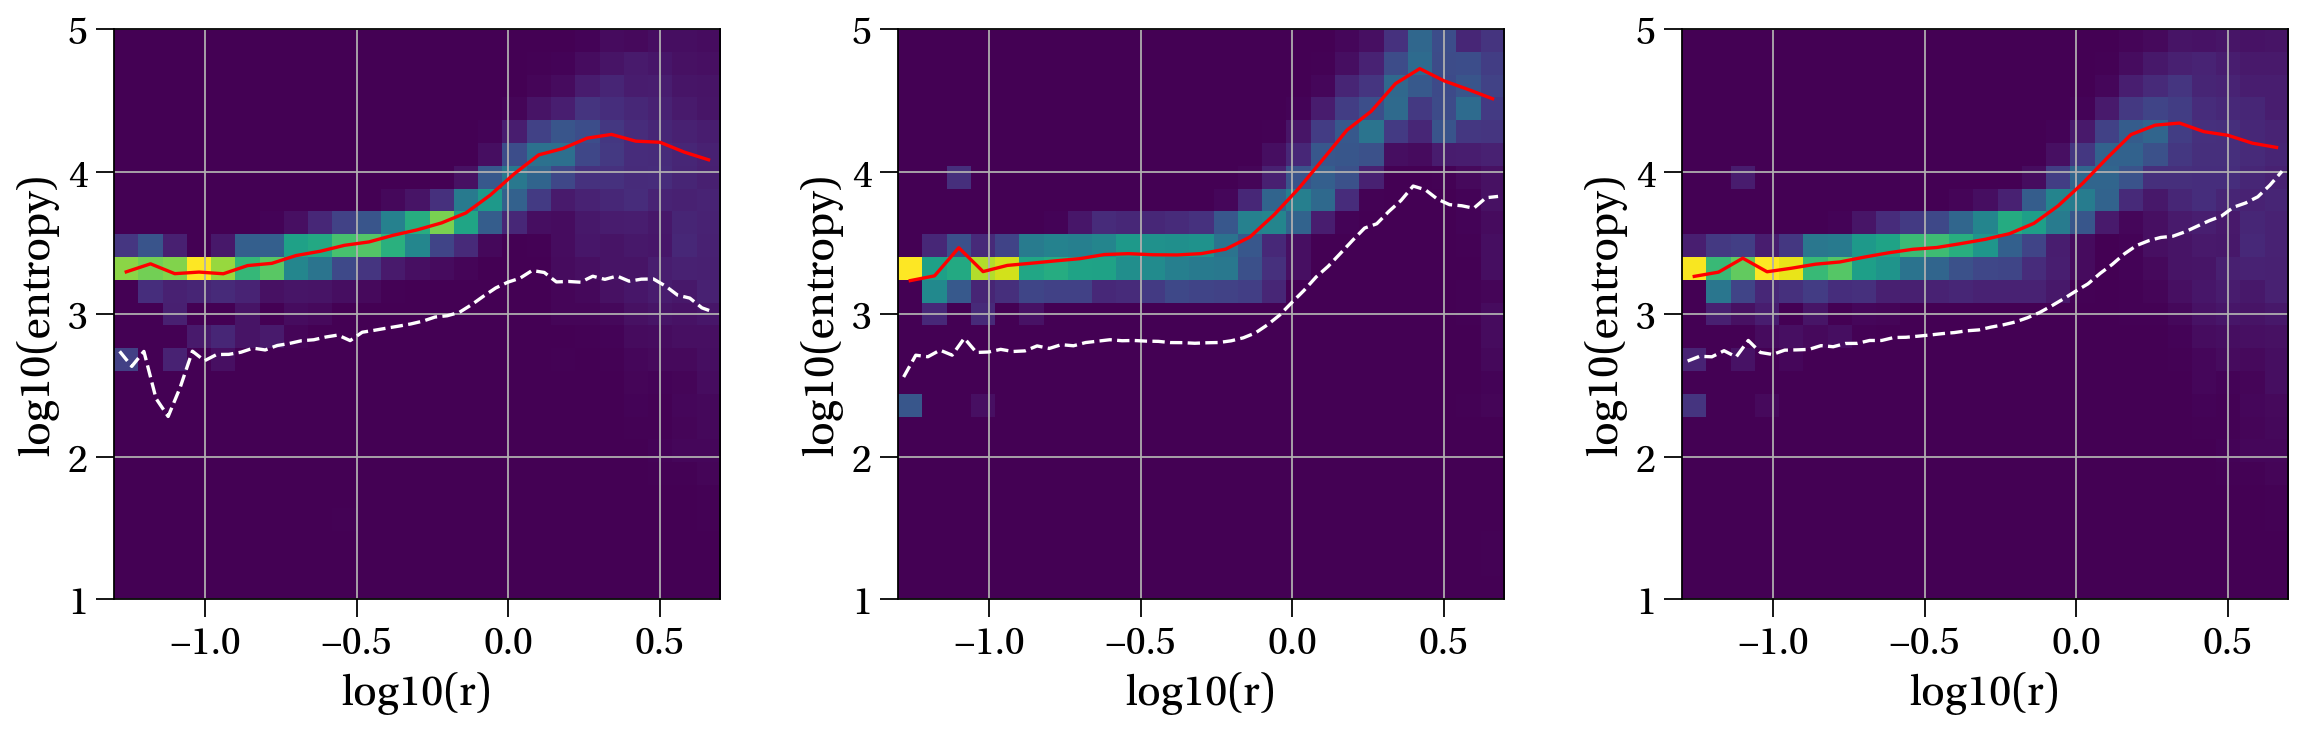

In [6]:
crosscheck_all(42)